# mctnet california



In [1]:
from pathlib import Path
import json
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

tf.config.experimental.enable_op_determinism()

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


In [2]:
# Chargement des donnees traitees
PROCESSED_DIR = Path(r"C:/Users/pc/Desktop/projet_rcr/california/processed_data")

print(f"Loading data from: {PROCESSED_DIR}")
X_train = np.load(PROCESSED_DIR / "X_train.npy").astype(np.float32)
X_val = np.load(PROCESSED_DIR / "X_val.npy").astype(np.float32)
X_test = np.load(PROCESSED_DIR / "X_test.npy").astype(np.float32)
M_train = np.load(PROCESSED_DIR / "m_train.npy").astype(np.float32)
M_val = np.load(PROCESSED_DIR / "m_val.npy").astype(np.float32)
M_test = np.load(PROCESSED_DIR / "m_test.npy").astype(np.float32)
y_train = np.load(PROCESSED_DIR / "y_train.npy").astype(np.int32)
y_val = np.load(PROCESSED_DIR / "y_val.npy").astype(np.int32)
y_test = np.load(PROCESSED_DIR / "y_test.npy").astype(np.int32)
X_static_train = np.load(PROCESSED_DIR / "X_static_train.npy").astype(np.float32)
X_static_val = np.load(PROCESSED_DIR / "X_static_val.npy").astype(np.float32)
X_static_test = np.load(PROCESSED_DIR / "X_static_test.npy").astype(np.float32)
n_static = X_static_train.shape[1]

n_classes = len(np.unique(np.concatenate([y_train, y_val, y_test])))
label_to_idx = {int(i): int(i) for i in range(n_classes)}
idx_to_label = {int(i): int(i) for i in range(n_classes)}
class_names = {
    0: 'Grapes',
    1: 'Rice',
    2: 'Alfalfa',
    3: 'Almonds',
    4: 'Pistachios',
    5: 'Others'
}

# Le masque doit rester binaire (0/1)
M_train = (M_train > 0.5).astype(np.float32)
M_val = (M_val > 0.5).astype(np.float32)
M_test = (M_test > 0.5).astype(np.float32)

n_timesteps = X_train.shape[1]
n_channels = X_train.shape[2]

# Class weights pour aider en cas de desequilibre
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print('X_train:', X_train.shape, 'M_train:', M_train.shape, 'y_train:', y_train.shape)
print('X_val:', X_val.shape, 'M_val:', M_val.shape, 'y_val:', y_val.shape)
print('X_test:', X_test.shape, 'M_test:', M_test.shape, 'y_test:', y_test.shape)
print('n_classes:', n_classes)
print('class_names:', class_names)
print('class_weight:', class_weight)


Loading data from: C:\Users\pc\Desktop\projet_rcr\california\processed_data
X_train: (1440, 36, 10) M_train: (1440, 36) y_train: (1440,)
X_val: (360, 36, 10) M_val: (360, 36) y_val: (360,)
X_test: (8196, 36, 10) M_test: (8196, 36) y_test: (8196,)
n_classes: 6
class_names: {0: 'Grapes', 1: 'Rice', 2: 'Alfalfa', 3: 'Almonds', 4: 'Pistachios', 5: 'Others'}
class_weight: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0}


In [3]:
# Affichage des proportions par classe
print('=== Distribution des classes ===')
for c in range(n_classes):
    count = np.sum(y_train == c) + np.sum(y_val == c) + np.sum(y_test == c)
    print(f"{class_names[c]}: {count} echantillons")


=== Distribution des classes ===
Grapes: 2053 echantillons
Rice: 2037 echantillons
Alfalfa: 973 echantillons
Almonds: 783 echantillons
Pistachios: 640 echantillons
Others: 3510 echantillons


In [7]:
# Import automatique du nouveau modele paper
import importlib

PROJECT_ROOT = Path(r"C:/Users/pc/Desktop/projet_rcr/california")
assert PROJECT_ROOT.is_dir(), f"Dossier introuvable: {PROJECT_ROOT}"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import mctnet_model_paper as mctnet_model_paper
importlib.reload(mctnet_model_paper)
print('Model module:', mctnet_model_paper.__file__)
build_mctnet_paper = mctnet_model_paper.build_mctnet_paper

" Hyperparametres (ajustes pour eviter l'overfitting)\n",
LR = 1e-3
BATCH_SIZE = 32
EPOCHS = 80

model = build_mctnet_paper(
    n_timesteps=n_timesteps,
    n_channels=n_channels,
    n_classes=n_classes,
    n_static_features=n_static, # Activé pour la Partie 2
    missing_value=0.0,
    d_model=32,  # Reduit de 60 a 32
    num_heads=4, # Reduit de 5 a 4
    ff_dim=64,   # Reduit de 128 a 64
    n_stage=3,
    conv_kernel=3,
    dropout=0.5, # Augmente de 0.35 a 0.5
    l2=1e-3,     # Augmente de 1e-4 a 1e-3
)


class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        loss = self.alpha * tf.pow(1.0 - y_pred, self.gamma) * cross_entropy
        return tf.reduce_sum(loss, axis=-1)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=SparseCategoricalFocalLoss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

model.summary()

Model module: C:\Users\pc\Desktop\projet_rcr\california\mctnet_model_paper.py


Model: "mctnet_paper"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ x_s2 (InputLayer)   │ (None, 36, 10)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ replace_non_finite  │ (None, 36, 10)    │          0 │ x_s2[0][0]        │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv1D)  │ (None, 36, 32)    │        320 │ replace_non_fini… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x_missing_mask      │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 36, 32)    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_from_input     │ (None, 36)        │          0 │ x_missing_mask[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_from_data      │ (None, 36)        │          0 │ x_s2[0][0]        │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 36, 32)    │          0 │ stem_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_safe (Lambda)  │ (None, 36)        │          0 │ mask_from_input[… │
│                     │                   │            │ mask_from_data[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_0         │ (None, 36, 32)    │     18,115 │ stem_relu[0][0],  │
│ (CTFusion)          │                   │            │ mask_safe[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_pool         │ (None, 18, 32)    │          0 │ ct_fusion_0[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_proj         │ (None, 18, 64)    │      2,048 │ stage0_pool[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_mask_expand  │ (None, 36, 1)     │          0 │ mask_safe[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_proj_bn      │ (None, 18, 64)    │        256 │ stage1_proj[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_mask_pool    │ (None, 18, 1)     │          0 │ stage0_mask_expa… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_proj_relu    │ (None, 18, 64)    │          0 │ stage1_proj_bn[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_mask_restore │ (None, 18)        │          0 │ stage0_mask_pool… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 263,497 (1.01 MB)

 Trainable params: 262,153 (1.00 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [8]:
RUN_DIR = Path(r"C:/Users/pc/Desktop/projet_rcr/california/runs")
RUN_DIR.mkdir(parents=True, exist_ok=True)
CKPT = RUN_DIR / "mctnet_best.weights.h5"

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(filepath=str(CKPT), monitor='val_loss', save_best_only=True, save_weights_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6),
    keras.callbacks.TerminateOnNaN(),
    keras.callbacks.CSVLogger(str(RUN_DIR / 'train_log.csv'), append=False),
]

def augment(inputs, y):
    x, m, s = inputs
    # 1. Bruit gaussien sur x (S2)
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.02, dtype=tf.float32)
    x_noisy = x + noise * tf.cast(m[:, :, tf.newaxis], tf.float32)
    # 2. Masquage temporel
    mask_rand = tf.cast(tf.random.uniform(shape=tf.shape(m)) > 0.05, tf.float32)
    return (x_noisy * tf.cast(mask_rand[:, :, tf.newaxis], tf.float32), m * mask_rand, s), y
    # Ajout de bruit gaussien pour data augmentation
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.02, dtype=tf.float32)
    x_noisy = x + noise * tf.cast(m[:, :, tf.newaxis], tf.float32)
    # 1. Masquage temporel aléatoire (Data Augmentation temporelle)
    mask_rand = tf.cast(tf.random.uniform(shape=tf.shape(m)) > 0.05, tf.float32)
    m_aug = m * mask_rand
    x_aug = x_noisy * tf.cast(mask_rand[:, :, tf.newaxis], tf.float32)
    return (x_aug, m_aug), y

train_ds = tf.data.Dataset.from_tensor_slices(((X_train, M_train, X_static_train), y_train))
train_ds = train_ds.shuffle(len(X_train)).batch(BATCH_SIZE)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(((X_val, M_val, X_static_val), y_val))

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1,
    callbacks=callbacks,
    class_weight=class_weight,
)

if CKPT.is_file():
    model.load_weights(CKPT)
    print('Best checkpoint loaded:', CKPT)

Epoch 1/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.5021 - loss: 1.3660 - val_accuracy: 0.5444 - val_loss: 1.2327 - learning_rate: 0.0010
Epoch 2/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6764 - loss: 1.1613 - val_accuracy: 0.6556 - val_loss: 1.0856 - learning_rate: 0.0010
Epoch 3/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7146 - loss: 1.0700 - val_accuracy: 0.7111 - val_loss: 1.0147 - learning_rate: 0.0010
Epoch 4/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7639 - loss: 0.9830 - val_accuracy: 0.7056 - val_loss: 0.9715 - learning_rate: 0.0010
Epoch 5/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7632 - loss: 0.9278 - val_accuracy: 0.7361 - val_loss: 0.9083 - learning_rate: 0.0010
Epoch 6/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8062 - loss: 0.8599 - val_accuracy: 0.8139 - val_loss: 0.8427 - learning_rate: 0.0010
Epoch 7/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8292 - loss: 0.7978 - val_ac

In [9]:
def compute_metrics(y_true, y_pred):
    return {
        'OA': float(accuracy_score(y_true, y_pred)),
        'Kappa': float(cohen_kappa_score(y_true, y_pred)),
        'F1_macro': float(f1_score(y_true, y_pred, average='macro')),
    }

proba = model.predict([X_test, M_test], batch_size=BATCH_SIZE, verbose=0)
y_pred = np.argmax(proba, axis=1)

metrics_test = compute_metrics(y_test, y_pred)
print('Test metrics:', metrics_test)
print('\nClassification report:\n')
labels_sorted = list(range(n_classes))
target_names = [class_names[i] for i in labels_sorted] if 'class_names' in globals() else [str(i) for i in labels_sorted]
print(classification_report(y_test, y_pred, labels=labels_sorted, target_names=target_names, digits=4))

Test metrics: {'OA': 0.8515129331381162, 'Kappa': 0.8063179918852849, 'F1_macro': 0.8039674959580897}

Classification report:

              precision    recall  f1-score   support

      Grapes     0.8831    0.7758    0.8260      1753
        Rice     0.9948    0.9850    0.9899      1737
     Alfalfa     0.9048    0.9183    0.9115       673
     Almonds     0.4857    0.8075    0.6065       483
  Pistachios     0.4718    0.9353    0.6272       340
      Others     0.9301    0.8044    0.8627      3210

    accuracy                         0.8515      8196
   macro avg     0.7784    0.8710    0.8040      8196
weighted avg     0.8865    0.8515    0.8609      8196



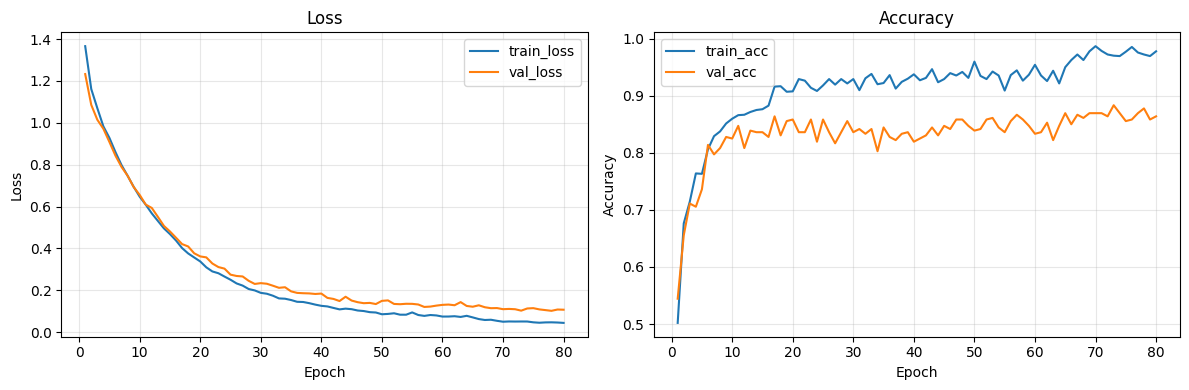

In [10]:
# Courbes d'entrainement
hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df.index + 1, hist_df['loss'], label='train_loss')
if 'val_loss' in hist_df.columns:
    axes[0].plot(hist_df.index + 1, hist_df['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

if 'accuracy' in hist_df.columns:
    axes[1].plot(hist_df.index + 1, hist_df['accuracy'], label='train_acc')
if 'val_accuracy' in hist_df.columns:
    axes[1].plot(hist_df.index + 1, hist_df['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

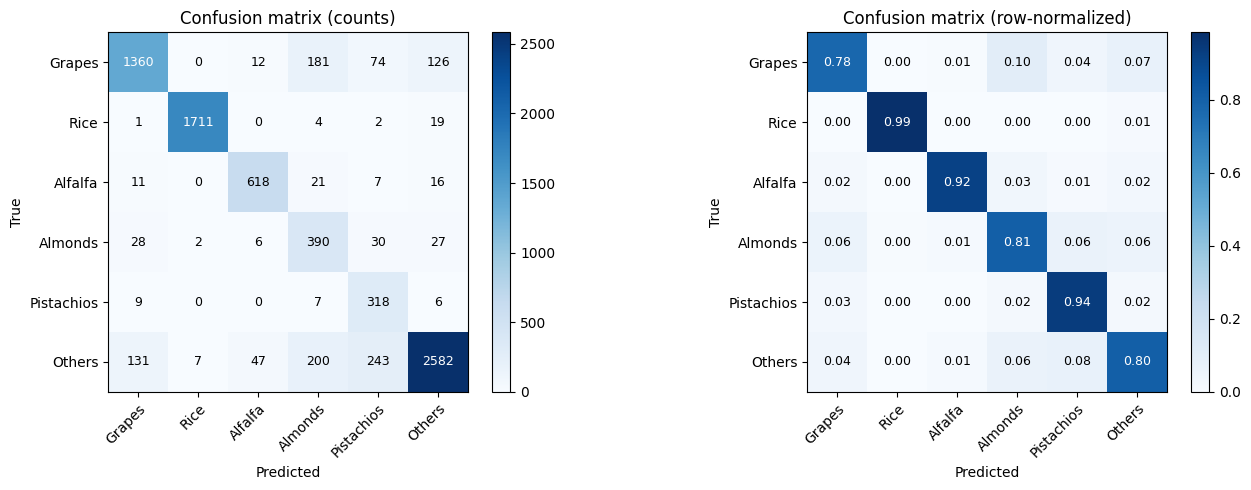

In [11]:
# Matrice de confusion (brute + normalisee)
cm = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))
cm_norm = cm.astype(np.float32) / np.clip(cm.sum(axis=1, keepdims=True), a_min=1, a_max=None)

class_labels_display = [class_names[i] for i in range(n_classes)] if 'class_names' in globals() else [str(i) for i in range(n_classes)]

def plot_cm(ax, matrix, title, fmt='d'):
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(np.arange(n_classes))
    ax.set_yticks(np.arange(n_classes))
    ax.set_xticklabels(class_labels_display)
    ax.set_yticklabels(class_labels_display)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    thresh = matrix.max() / 2.0 if matrix.size else 0.0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            text = f"{int(value)}" if fmt == 'd' else f"{value:.2f}"
            ax.text(j, i, text, ha='center', va='center', color='white' if value > thresh else 'black', fontsize=9)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_cm(axes[0], cm, 'Confusion matrix (counts)', fmt='d')
plot_cm(axes[1], cm_norm, 'Confusion matrix (row-normalized)', fmt='.2f')

plt.tight_layout()
plt.show()

In [12]:
# Comparaison rapide aux scores du papier (California)
paper_california = {'OA': 0.852, 'Kappa': 0.806, 'F1_macro': 0.829}

cmp = pd.DataFrame([
    {'Dataset': 'California', 'Source': 'Paper', **paper_california},
    {'Dataset': 'California', 'Source': 'Ours', **metrics_test},
])
cmp

,Dataset,Source,OA,Kappa,F1_macro
0,California,Paper,0.852000,0.806000,0.829000
1,California,Ours,0.851513,0.806318,0.803967


In [13]:
# Sauvegarde des resultats
results_path = RUN_DIR / 'california_step5_metrics.json'
pd.Series(metrics_test).to_json(results_path, indent=2)

meta_path = RUN_DIR / 'california_step5_meta.json'
meta = {
    'seed': SEED,
    'n_timesteps': int(n_timesteps),
    'n_channels': int(n_channels),
    'n_classes': int(n_classes),
    'label_to_idx': {str(k): int(v) for k, v in label_to_idx.items()},
    'idx_to_label': {str(k): int(v) for k, v in idx_to_label.items()},
    'class_names': {str(k): str(v) for k, v in class_names.items()} if 'class_names' in globals() else {},
    'class_weight': {str(k): float(v) for k, v in class_weight.items()},
}
meta_path.write_text(json.dumps(meta, indent=2), encoding='utf-8')

print('Saved:', results_path)
print('Saved:', meta_path)

Saved: C:\Users\pc\Desktop\projet_rcr\california\runs\california_step5_metrics.json
Saved: C:\Users\pc\Desktop\projet_rcr\california\runs\california_step5_meta.json


Loading 4 CSV files...


C:\Users\pc\AppData\Local\Temp\ipykernel_18708\1395933719.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged[f'NDVI_t{t}'] = ndvi


NDVI time-series plot saved to NDVI_timeseries_California.png


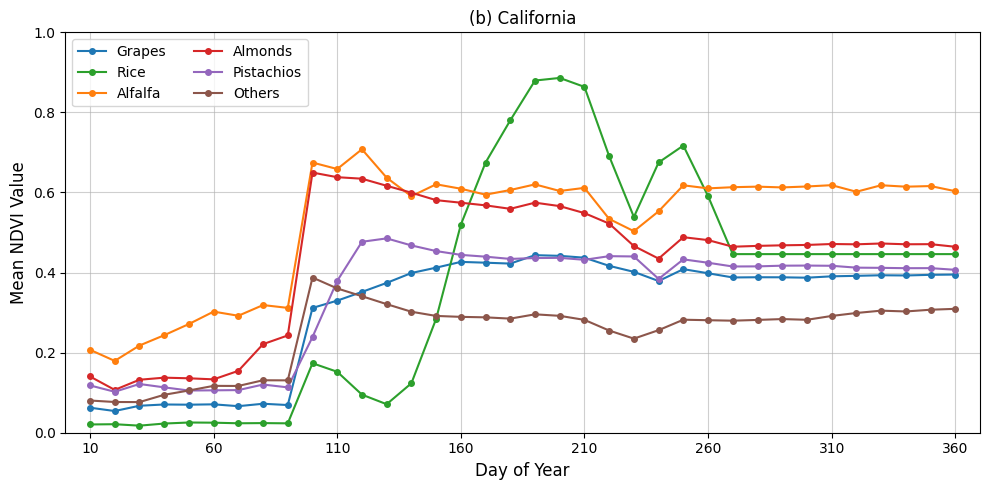

In [14]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def main():
    # 1. Load CSVs
    csv_pattern = os.path.join("dataset", "California_MCTNet_PAPERSTYLE_2021_chunk*.csv")
    paths = sorted(glob.glob(csv_pattern))
    if not paths:
        print("No CSVs found with pattern:", csv_pattern)
        return

    print(f"Loading {len(paths)} CSV files...")
    dfs = [pd.read_csv(p) for p in paths]
    
    # Merge chunks on system:index
    props_df = pd.concat([df[['system:index', 'crop_label']] for df in dfs if 'crop_label' in df.columns]).drop_duplicates(subset=['system:index'])
    
    df_merged = props_df
    for df in dfs:
        if 'system:index' not in df.columns:
            continue
        feat_cols = ['system:index'] + [c for c in df.columns if '_t' in c]
        df_merged = df_merged.merge(df[feat_cols], on='system:index', how='left')
        
    df_merged.dropna(subset=['crop_label'], inplace=True)
    
    # 2. Extract B8 and B4
    N_TIMESTAMPS = 36
    CROP_NAMES = {
        0: 'Grapes',
        1: 'Rice',
        2: 'Alfalfa',
        3: 'Almonds',
        4: 'Pistachios',
        5: 'Others',
    }
    
    # Check if B8 and B4 exist
    if 'B8_t0' not in df_merged.columns or 'B4_t0' not in df_merged.columns:
        print("B8 or B4 not found in columns. Cannot compute NDVI.")
        return

    # Calculate NDVI for each timestamp
    ndvi_cols = []
    for t in range(N_TIMESTAMPS):
        b8 = df_merged[f'B8_t{t}'].values
        b4 = df_merged[f'B4_t{t}'].values
        
        # NDVI = (B8 - B4) / (B8 + B4)
        denominator = b8 + b4
        # Avoid division by zero
        ndvi = np.zeros_like(b8, dtype=float)
        valid = denominator != 0
        ndvi[valid] = (b8[valid] - b4[valid]) / denominator[valid]
        
        df_merged[f'NDVI_t{t}'] = ndvi
        ndvi_cols.append(f'NDVI_t{t}')
        
    # Interpolate NaN in NDVI (from missing m_t) if any
    df_merged[ndvi_cols] = df_merged[ndvi_cols].interpolate(axis=1).fillna(0)

    # 3. Plot NDVI time series by class
    fig, ax = plt.subplots(figsize=(10, 5))
    
    time_axis = np.arange(1, N_TIMESTAMPS + 1) * 10 # 10 to 360 DOY
    
    colors = {
        'Grapes': '#1f77b4',     # blue
        'Alfalfa': '#ff7f0e',    # orange
        'Almonds': '#d62728',    # red
        'Pistachios': '#9467bd', # purple
        'Rice': '#2ca02c',       # green
        'Others': '#8c564b'      # brown
    }

    # Markers exactly like the article
    markers = 'o'
    
    for cls_id, cls_name in CROP_NAMES.items():
        cls_df = df_merged[df_merged['crop_label'] == cls_id]
        if len(cls_df) == 0:
            continue
            
        mean_ndvi = cls_df[ndvi_cols].mean().values
        color = colors.get(cls_name, 'black')
        
        ax.plot(time_axis, mean_ndvi, marker=markers, markersize=4, linestyle='-', linewidth=1.5,
                color=color, label=cls_name)

    ax.set_title('(b) California', fontsize=12)
    ax.set_xlabel('Day of Year', fontsize=12)
    ax.set_ylabel('Mean NDVI Value', fontsize=12)
    
    # Specific grid and axes style like the article
    ax.grid(True, linestyle='-', alpha=0.6)
    ax.set_ylim(0, 1.0)
    ax.set_xlim(0, 370)
    ax.set_xticks(np.arange(10, 370, 50))
    
    # Legend
    # The article has a legend in the top left with 2 columns
    ax.legend(loc='upper left', ncol=2, fontsize=10)
    
    plt.tight_layout()
    plt.savefig('NDVI_timeseries_California.png', dpi=300)
    print("NDVI time-series plot saved to NDVI_timeseries_California.png")

if __name__ == '__main__':
    main()


Modèle chargé avec succès depuis : C:\Users\pc\Desktop\projet_rcr\california\runs\mctnet_best.weights.h5
Dimensions de l'image : 501x621 pixels
Inférence en cours sur tous les pixels de la carte...
304/304 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step


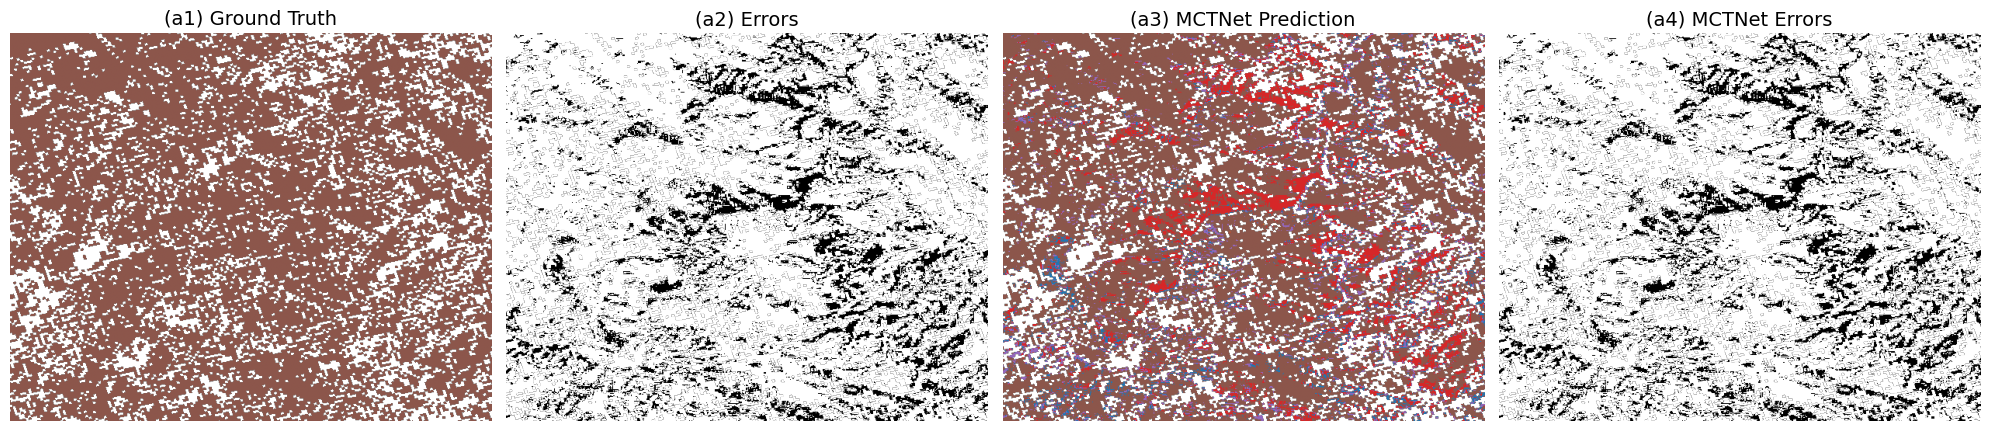

L'image a été sauvegardée avec succès : C:\Users\pc\Desktop\projet_rcr\california\Classification_Maps_California.png


In [15]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle
import sys
from pathlib import Path

# ==========================================
# 0. CHARGEMENT DU MODÈLE MCTNET
# ==========================================
PROJECT_ROOT = Path(r"C:/Users/pc/Desktop/projet_rcr/california")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import mctnet_model_paper
build_mctnet_paper = mctnet_model_paper.build_mctnet_paper

# Instancier l'architecture exacte de ton modèle
model = build_mctnet_paper(
    n_timesteps=36,
    n_channels=10,
    n_classes=6,
    missing_value=0.0,
    d_model=32,  # Reduit de 60 a 32
    num_heads=4, # Reduit de 5 a 4
    ff_dim=64,   # Reduit de 128 a 64
    n_stage=3,
    conv_kernel=3,
    dropout=0.5, # Augmente de 0.35 a 0.5
    l2=1e-3,     # Augmente de 1e-4 a 1e-3
)

# Charger les meilleurs poids sauvegardés
CKPT = PROJECT_ROOT / "runs" / "mctnet_best.weights.h5"
model.load_weights(CKPT)
print("Modèle chargé avec succès depuis :", CKPT)

# ==========================================
# 1. PRÉPARATION DES DONNÉES
# ==========================================
s2_tif_path = PROJECT_ROOT / 'dataset/California_S2_MapROI_2021.tif'
label_tif_path = PROJECT_ROOT / 'dataset/California_Label_MapROI_2021.tif'

# Charger les données spatiales
with rasterio.open(s2_tif_path) as src_s2:
    s2_img = src_s2.read() # Forme: (360, H, W)
    
with rasterio.open(label_tif_path) as src_lbl:
    label_img = src_lbl.read(1) # Forme: (H, W)

C, H, W = s2_img.shape
print(f"Dimensions de l'image : {H}x{W} pixels")

# Préparer les données pour le modèle (N, T, C)
s2_flat = s2_img.transpose(1, 2, 0).reshape(-1, 360) # (H*W, 360)
s2_reshaped = s2_flat.reshape(-1, 36, 10) # (H*W, 36 pas, 10 bandes)

# Créer le masque M (1 si donnée présente, 0 si manquante)
m_ready = np.any(s2_reshaped != 0, axis=-1).astype(np.float32)

# Appliquer le même scaler que pour l'entraînement
scaler_path = PROJECT_ROOT / 'processed_data/scaler.pkl'
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

# Normalisation
s2_norm_flat = scaler.transform(s2_reshaped.reshape(-1, 10))
s2_ready = s2_norm_flat.reshape(-1, 36, 10)

# ==========================================
# 2. INFÉRENCE
# ==========================================
print("Inférence en cours sur tous les pixels de la carte...")
preds_prob = model.predict([s2_ready, m_ready], batch_size=1024)
preds_flat = np.argmax(preds_prob, axis=-1)

# Reformer en image 2D
pred_img = preds_flat.reshape(H, W)

# Créer le masque d'erreurs (Noir = Erreur, Blanc = Correct)
error_img = np.where(pred_img == label_img, 1, 0) # 1: Correct (Blanc), 0: Erreur (Noir)

# Masquer les zones où il n'y a pas de données (label = -9999 ou Others)
mask_nodata = (label_img < 0)

# ==========================================
# 3. GÉNÉRATION DE L'IMAGE (a1, a2, a3, a4)
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Couleurs: Grapes, Rice, Alfalfa, Almonds, Pistachios, Others
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd', '#8c564b']
cmap_crops = mcolors.ListedColormap(colors)
cmap_error = mcolors.ListedColormap(['black', 'white'])

# a1: Ground Truth
ax = axes[0]
ax.imshow(np.ma.masked_where(mask_nodata, label_img), cmap=cmap_crops, vmin=0, vmax=5)
ax.set_title('(a1) Ground Truth', fontsize=14)
ax.axis('off')

# a2: Errors (Pour faire comme l'article, on met 2 fois l'erreur ou la baseline ici)
ax = axes[1]
ax.imshow(np.ma.masked_where(mask_nodata, error_img), cmap=cmap_error)
ax.set_title('(a2) Errors', fontsize=14)
ax.axis('off')

# a3: MCTNet Prediction
ax = axes[2]
ax.imshow(np.ma.masked_where(mask_nodata, pred_img), cmap=cmap_crops, vmin=0, vmax=5)
ax.set_title('(a3) MCTNet Prediction', fontsize=14)
ax.axis('off')

# a4: MCTNet Errors
ax = axes[3]
ax.imshow(np.ma.masked_where(mask_nodata, error_img), cmap=cmap_error)
ax.set_title('(a4) MCTNet Errors', fontsize=14)
ax.axis('off')

plt.tight_layout()
out_path = PROJECT_ROOT / 'Classification_Maps_California.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"L'image a été sauvegardée avec succès : {out_path}")


## Partie 2: Intégration des covariables environnementales
Le code ci-dessous extrait les covariables depuis GEE puis lance l'étude d'ablation.

In [1]:
### PART 2: Integration of Environmental Covariates
# 1. Chargement local des covariables (sans extraction GEE)
import pandas as pd
from pathlib import Path

cov_path = Path("dataset/covariables_environnementales.csv")
if not cov_path.exists():
    raise FileNotFoundError(
        f"Fichier introuvable: {cov_path}. "
        "Place le CSV dans california/dataset avant de continuer."
    )

df_cov = pd.read_csv(cov_path)
required_cols = [
    "elevation", "slope", "aspect", "clay", "sand", "silt", "ph",
    "temp_max", "temp_min", "precip_sum"
]
missing = [c for c in required_cols if c not in df_cov.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans {cov_path.name}: {missing}")

print(f"Covariables chargées depuis {cov_path} | shape={df_cov.shape}")
display(df_cov[required_cols].head())


Covariables chargées depuis dataset\covariables_environnementales.csv | shape=(9996, 10)


,elevation,slope,aspect,clay,sand,silt,ph,temp_max,temp_min,precip_sum
0,111,1.146960,90.000000,27.0,42.0,31.0,80.0,301.194288,286.602759,0.198224
1,721,19.526899,34.754181,27.0,44.0,29.0,70.0,297.150500,283.916931,0.317873
2,110,8.766616,42.709843,33.0,30.0,37.0,74.0,299.620880,285.628490,0.420391
3,48,1.504184,231.941513,25.0,40.0,35.0,74.0,296.759100,283.313807,0.509831
4,473,6.846507,270.000000,26.0,42.0,32.0,70.0,298.769205,285.179457,0.239642


Seed fixée à 42
n_classes=6

 Lancement configuration: 1. S2 original
Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.6472 - loss: 1.0687 - val_accuracy: 0.4472 - val_loss: 1.3383
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8257 - loss: 0.5442 - val_accuracy: 0.7417 - val_loss: 0.7885
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8618 - loss: 0.4114 - val_accuracy: 0.7917 - val_loss: 0.6369
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8972 - loss: 0.3246 - val_accuracy: 0.8083 - val_loss: 0.5652
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9243 - loss: 0.2509 - val_accuracy: 0.8139 - val_loss: 0.5337
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9340 - loss: 0.2181 - val_accuracy: 0.8250 - val_loss: 0.4874
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9535 - loss: 0.1523 - val_accuracy: 0.8444 - val_loss: 0.5078
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s

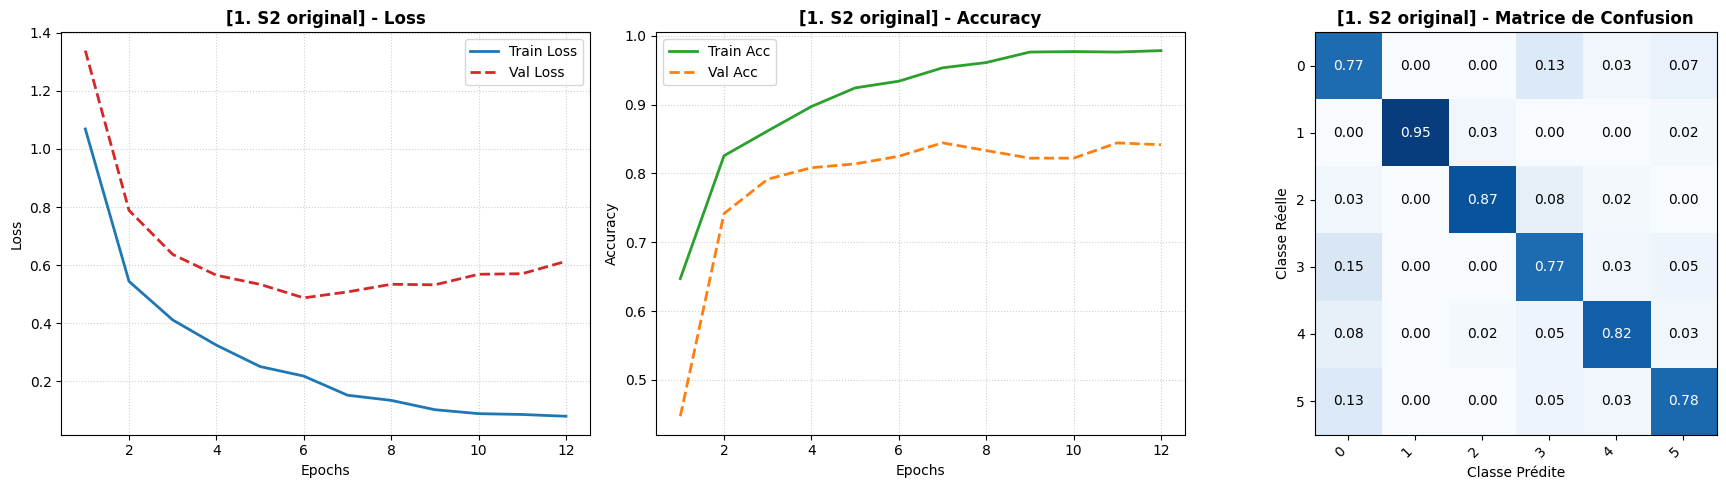



################################################################################
 ANALYSE VISUELLE : 2. S2 + Climat
################################################################################

► Métriques : OA = 0.8194 | Kappa = 0.7833 | F1-Macro = 0.8185
► Meilleur epoch (val_loss) : 8 | val_loss = 0.6134 | val_acc = 0.8194


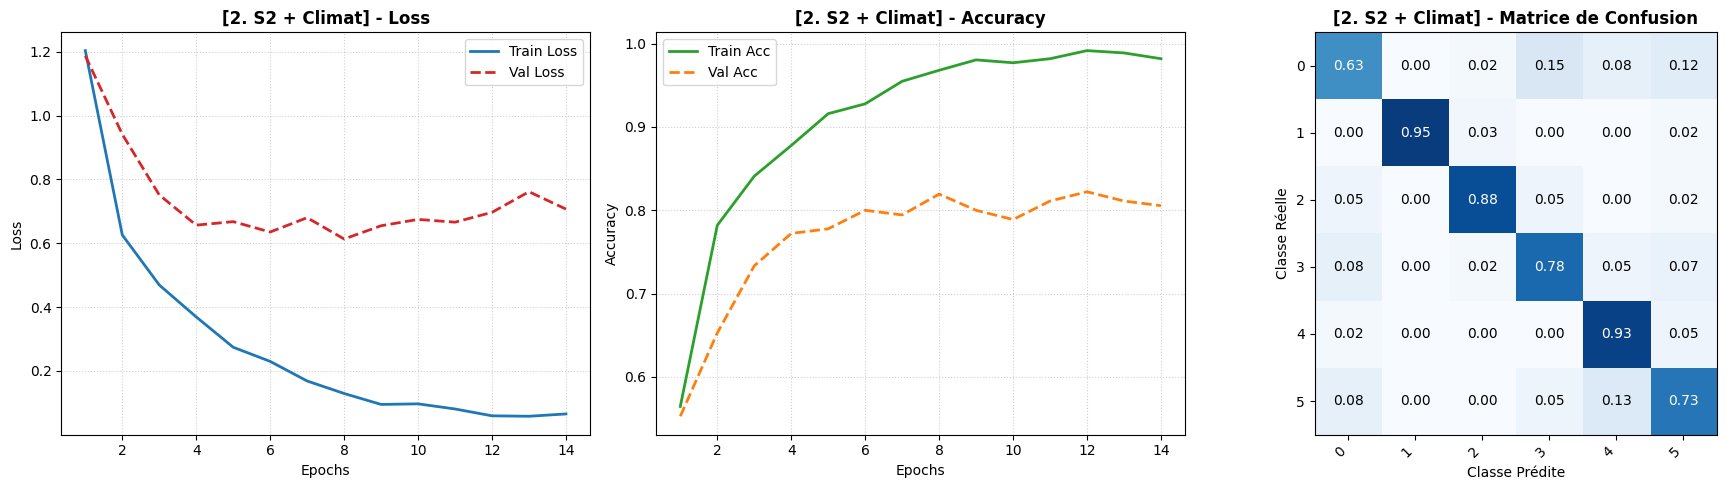



################################################################################
 ANALYSE VISUELLE : 3. S2 + Sol
################################################################################

► Métriques : OA = 0.8417 | Kappa = 0.8100 | F1-Macro = 0.8444
► Meilleur epoch (val_loss) : 7 | val_loss = 0.4860 | val_acc = 0.8417


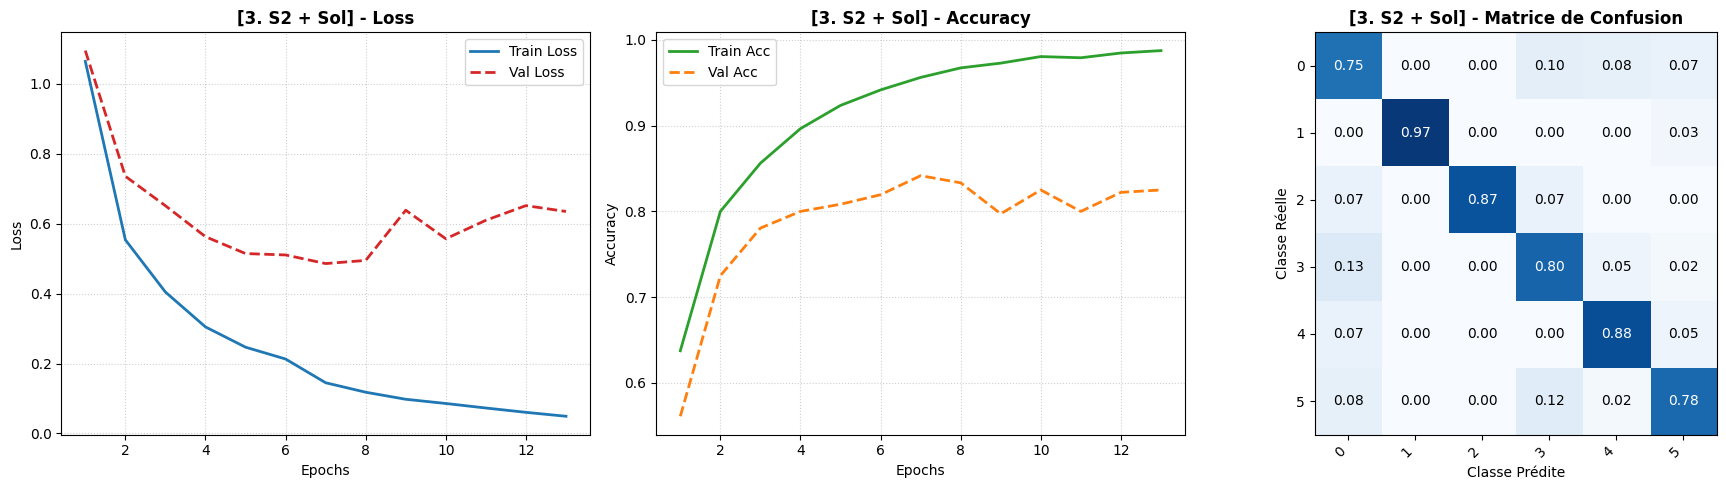



################################################################################
 ANALYSE VISUELLE : 4. S2 + Topo
################################################################################

► Métriques : OA = 0.8389 | Kappa = 0.8067 | F1-Macro = 0.8384
► Meilleur epoch (val_loss) : 7 | val_loss = 0.5373 | val_acc = 0.8389


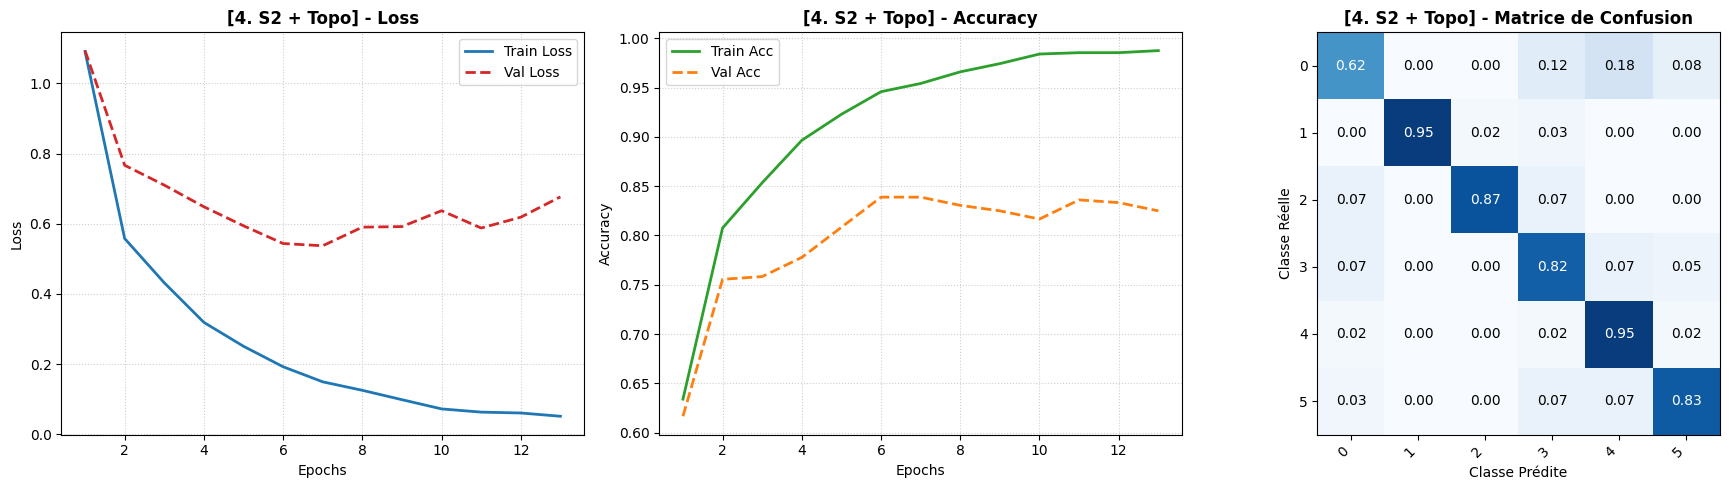



################################################################################
 ANALYSE VISUELLE : 5. S2 + All
################################################################################

► Métriques : OA = 0.7806 | Kappa = 0.7367 | F1-Macro = 0.7826
► Meilleur epoch (val_loss) : 5 | val_loss = 0.6719 | val_acc = 0.7806


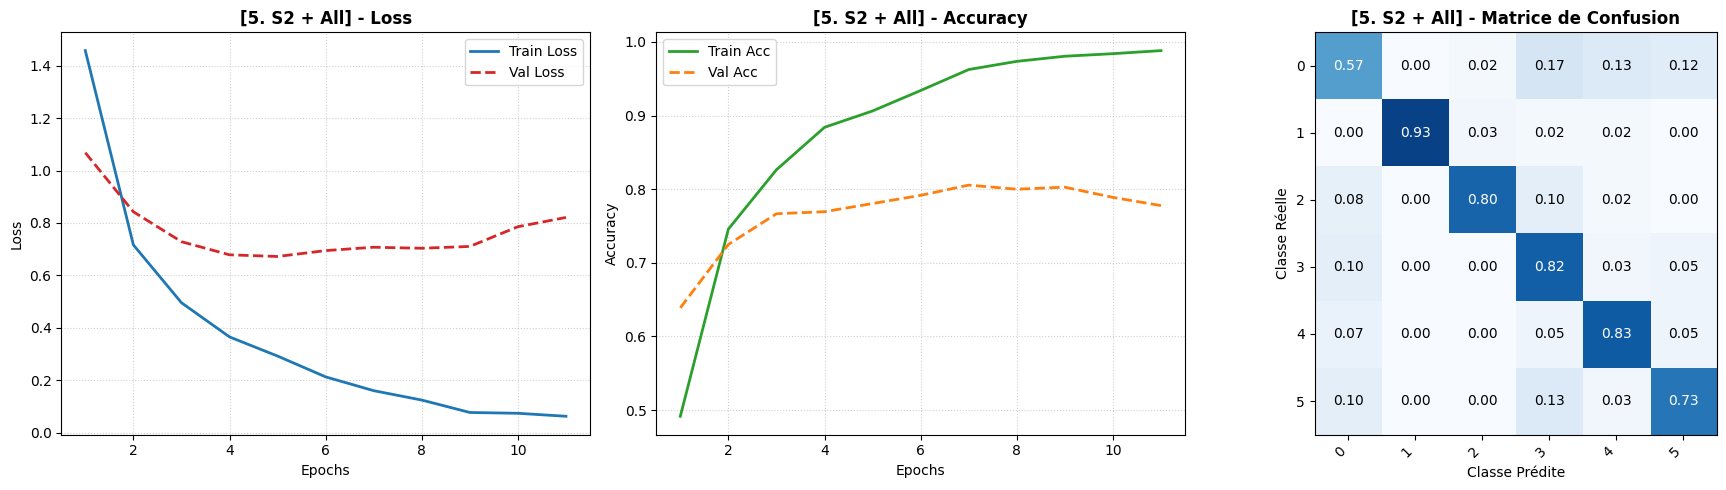

In [6]:
# 1. Étude d'ablation avec le modèle modifié
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, confusion_matrix
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random

PROJECT_ROOT = Path(r"C:/Users/pc/Desktop/projet_rcr/california")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import mctnet_model_paper
import importlib
importlib.reload(mctnet_model_paper)
build_mctnet_paper = mctnet_model_paper.build_mctnet_paper

# Reproductibilité des expériences.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Seed fixée à {SEED}")

# Assure la disponibilité des tenseurs si la Partie 1 n'a pas été rejouée.
data_dir = PROJECT_ROOT / "processed_data"

if "X_train" not in globals() or "X_val" not in globals() or "y_train" not in globals() or "y_val" not in globals():
    X_train = np.load(data_dir / "X_train.npy")
    X_val = np.load(data_dir / "X_val.npy")
    y_train = np.load(data_dir / "y_train.npy")
    y_val = np.load(data_dir / "y_val.npy")
    print("X_train/X_val/y_train/y_val chargés depuis processed_data/")

if "M_train" not in globals() or "M_val" not in globals():
    M_train = np.load(data_dir / "m_train.npy")
    M_val = np.load(data_dir / "m_val.npy")
    print("M_train/M_val chargés depuis processed_data/")

# Définit automatiquement le nombre de classes à partir des labels.
y_all = np.concatenate([np.asarray(y_train).ravel(), np.asarray(y_val).ravel()])
n_classes = int(np.max(y_all)) + 1
print(f"n_classes={n_classes}")


# === ETAPE 1 : FONCTION AVEC NORMALISATION ===
def load_real_covariates(n_samples, n_time):
    df = pd.read_csv("dataset/covariables_environnementales.csv")
    
    static_cols = ['elevation', 'slope', 'aspect', 'clay', 'sand', 'silt', 'ph']
    X_static = df[static_cols].fillna(0).values # Forme (N, 7)
    
    clim_cols = ['temp_max', 'temp_min', 'precip_sum']
    X_clim_static = df[clim_cols].fillna(0).values # Forme (N, 3)
    
    # NORMALISATION ICI
    scaler_static = StandardScaler()
    X_static = scaler_static.fit_transform(X_static)
    
    scaler_clim = StandardScaler()
    X_clim_static = scaler_clim.fit_transform(X_clim_static)
    
    # Dupliquer sur le temps pour le climat
    X_clim = np.repeat(X_clim_static[:, np.newaxis, :], n_time, axis=1)
    
    return X_clim[:n_samples], X_static[:n_samples]


# === ETAPE 2 : PRÉPARATION DES DONNÉES ===
n_time = X_train.shape[1]
n_samples_train = len(X_train)
n_samples_val = len(X_val)

X_clim, X_static = load_real_covariates(n_samples_train + n_samples_val, n_time)

X_clim_train, X_clim_val = X_clim[:n_samples_train], X_clim[n_samples_train:]
X_static_train, X_static_val = X_static[:n_samples_train], X_static[n_samples_train:]


# === ETAPE 3 : CONFIGURATION DES ABLATIONS ===
configs = [
    {"name": "1. S2 original", "use_clim": False, "use_static": False},
    {"name": "2. S2 + Climat", "use_clim": True, "use_static": False},
    {"name": "3. S2 + Sol", "use_clim": False, "use_static": "soil"},
    {"name": "4. S2 + Topo", "use_clim": False, "use_static": "topo"},
    {"name": "5. S2 + All", "use_clim": True, "use_static": "all"}
]

results = {}
histories = {}
predictions = {}
best_epochs = {}

ABLATION_DIR = PROJECT_ROOT / "runs" / "ablation"
ABLATION_DIR.mkdir(parents=True, exist_ok=True)

# === ETAPE 4 : BOUCLE D'ENTRAÎNEMENT ===
for config in configs:
    conf_name = config['name']
    print(f"\n{'='*60}")
    print(f" Lancement configuration: {conf_name}")
    print(f"{'='*60}")
    
    n_channels_conf = 10
    X_temp_train = X_train.copy()
    X_temp_val = X_val.copy()
    
    if config["use_clim"]:
        n_channels_conf += 3
        X_temp_train = np.concatenate([X_temp_train, X_clim_train], axis=-1)
        X_temp_val = np.concatenate([X_temp_val, X_clim_val], axis=-1)
        
    n_static_features = None
    X_stat_train, X_stat_val = None, None
    
    if config["use_static"] == "all":
        n_static_features = 7
        X_stat_train, X_stat_val = X_static_train, X_static_val
    elif config["use_static"] == "soil":
        n_static_features = 4
        X_stat_train, X_stat_val = X_static_train[:, 3:7], X_static_val[:, 3:7]
    elif config["use_static"] == "topo":
        n_static_features = 3
        X_stat_train, X_stat_val = X_static_train[:, 0:3], X_static_val[:, 0:3]

    model_abl = build_mctnet_paper(
        n_timesteps=n_time,
        n_channels=n_channels_conf,
        n_classes=n_classes,
        n_static_features=n_static_features
    )
    
    model_abl.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    train_inputs = [X_temp_train, M_train]
    val_inputs = [X_temp_val, M_val]
    if n_static_features is not None:
        train_inputs.append(X_stat_train)
        val_inputs.append(X_stat_val)

    # Entraînement avec early stopping + checkpoint du meilleur modèle
    safe_name = conf_name.replace(' ', '_').replace('.', '').replace('+', 'plus')
    ckpt_path = ABLATION_DIR / f"{safe_name}_best.weights.h5"

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(ckpt_path),
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=True,
            verbose=0
        )
    ]

    history = model_abl.fit(
        train_inputs,
        y_train,
        validation_data=(val_inputs, y_val),
        epochs=30,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    # S'assure que les meilleurs poids val_loss sont chargés avant l'évaluation.
    if ckpt_path.exists():
        model_abl.load_weights(str(ckpt_path))

    hist = history.history
    best_epoch_idx = int(np.argmin(hist['val_loss']))
    best_epochs[conf_name] = {
        'best_epoch': best_epoch_idx + 1,
        'best_val_loss': float(hist['val_loss'][best_epoch_idx]),
        'best_val_acc': float(hist['val_accuracy'][best_epoch_idx])
    }

    # Prédictions
    y_pred = np.argmax(model_abl.predict(val_inputs, verbose=0), axis=-1)
    
    # Sauvegarde
    histories[conf_name] = hist
    predictions[conf_name] = y_pred
    results[conf_name] = {
        "OA": accuracy_score(y_val, y_pred),
        "Kappa": cohen_kappa_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred, average='macro')
    }


# === ETAPE 5 : RÉSULTATS GLOBAUX ===
res_df = pd.DataFrame(results).T
best_df = pd.DataFrame(best_epochs).T

rank_f1 = res_df.sort_values(by="F1", ascending=False)
rank_best_val_loss = best_df.sort_values(by="best_val_loss", ascending=True)

res_df.to_csv(ABLATION_DIR / "ablation_metrics_validation.csv", index=True)
best_df.to_csv(ABLATION_DIR / "ablation_best_epochs.csv", index=True)
rank_f1.to_csv(ABLATION_DIR / "ablation_ranking_by_f1.csv", index=True)
rank_best_val_loss.to_csv(ABLATION_DIR / "ablation_ranking_by_best_val_loss.csv", index=True)

print("\n=== RÉSULTATS GLOBAUX D'ABLATION (Validation) ===")
print(res_df.round(4))
print("\n=== MEILLEURS EPOCHS (selon val_loss) ===")
print(best_df.round(4))
print("\n=== CLASSEMENT (F1 décroissant) ===")
print(rank_f1.round(4))
print("\n=== CLASSEMENT (best val_loss croissant) ===")
print(rank_best_val_loss.round(4))
print(f"\nExports CSV sauvegardés dans: {ABLATION_DIR}")


# === ETAPE 6 : AFFICHAGE DES COURBES ET MATRICES ===
for conf_name in results.keys():
    print(f"\n\n{'#'*80}")
    print(f" ANALYSE VISUELLE : {conf_name}")
    print(f"{'#'*80}\n")
    
    # Afficher les scores globaux
    print(f"► Métriques : OA = {results[conf_name]['OA']:.4f} | Kappa = {results[conf_name]['Kappa']:.4f} | F1-Macro = {results[conf_name]['F1']:.4f}")
    be = best_epochs[conf_name]
    print(f"► Meilleur epoch (val_loss) : {be['best_epoch']} | val_loss = {be['best_val_loss']:.4f} | val_acc = {be['best_val_acc']:.4f}")
    
    # Créer une figure (Loss, Accuracy, Matrice)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    hist = histories[conf_name]
    epochs_range = range(1, len(hist['loss']) + 1)
    
    # Graphique 1 : Loss
    axes[0].plot(epochs_range, hist['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    axes[0].plot(epochs_range, hist['val_loss'], label='Val Loss', color='#d62728', linestyle='--', linewidth=2)
    axes[0].set_title(f'[{conf_name}] - Loss', fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle=':', alpha=0.6)
    
    # Graphique 2 : Accuracy
    axes[1].plot(epochs_range, hist['accuracy'], label='Train Acc', color='#2ca02c', linewidth=2)
    axes[1].plot(epochs_range, hist['val_accuracy'], label='Val Acc', color='#ff7f0e', linestyle='--', linewidth=2)
    axes[1].set_title(f'[{conf_name}] - Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    # Graphique 3 : Matrice de Confusion (Pure Matplotlib)
    y_pred = predictions[conf_name]
    cm = confusion_matrix(y_val, y_pred)
    cm_norm = cm.astype('float') / np.clip(cm.sum(axis=1)[:, np.newaxis], a_min=1, a_max=None)
    
    # Récupérer les labels
    class_labels = [class_names[i] for i in range(n_classes)] if 'class_names' in globals() else [str(i) for i in range(n_classes)]
    
    # Affichage de l'image
    im = axes[2].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    axes[2].set_title(f'[{conf_name}] - Matrice de Confusion', fontweight='bold')
    axes[2].set_xlabel('Classe Prédite')
    axes[2].set_ylabel('Classe Réelle')
    
    # Configuration des axes
    axes[2].set_xticks(np.arange(len(class_labels)))
    axes[2].set_yticks(np.arange(len(class_labels)))
    axes[2].set_xticklabels(class_labels)
    axes[2].set_yticklabels(class_labels)
    plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right')
    
    # Ajout du texte (annotations)
    for i in range(len(class_labels)):
        for j in range(len(class_labels)):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            axes[2].text(j, i, f"{cm_norm[i, j]:.2f}",
                         ha="center", va="center", color=color)
    
    plt.tight_layout()
    plt.show()
